In [1]:
import os
import subprocess
import sys

# ========== CONFIGURATION ==========
REPO_URL = "https://github.com/MuhammadQaiser1921/swin-model.git"
REPO_NAME = "swin-model"
REPO_BRANCH = "AF_V1"  # <--- Specify your branch here
REPO_PATH = f"/kaggle/working/{REPO_NAME}"

# ========== CLONE OR PULL REPO ==========
if not os.path.exists(REPO_PATH):
    print(f"📌 Cloning branch '{REPO_BRANCH}' from {REPO_URL}...")
    # Clone specifically the chosen branch
    subprocess.run(["git", "clone", "-b", REPO_BRANCH, REPO_URL], check=True)
else:
    print(f"📌 Repository exists. Fetching updates for branch '{REPO_BRANCH}'...")
    os.chdir(REPO_PATH)
    
    # Reset local changes and fetch all updates
    subprocess.run(["git", "reset", "--hard"], check=True)
    subprocess.run(["git", "fetch", "--all"], check=True)
    
    # Ensure we are on the correct branch and pull the latest changes
    subprocess.run(["git", "checkout", REPO_BRANCH], check=True)
    subprocess.run(["git", "pull", "origin", REPO_BRANCH], check=True)
    
    os.chdir("/kaggle/working")

# ========== SETUP PATHS & REQUIREMENTS ==========
# Add the src directory where your files are located
sys.path.append(f"{REPO_PATH}/src")

# Install requirements if the file exists in your repo
req_file = f"{REPO_PATH}/requirements.txt"
if os.path.exists(req_file):
    print("Installing requirements...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", req_file], check=True)

print(f"✅ Repository (Branch: {REPO_BRANCH}) is ready and paths are configured.")

📌 Cloning branch 'AF_V1' from https://github.com/MuhammadQaiser1921/swin-model.git...


Cloning into 'swin-model'...


Installing requirements...
✅ Repository (Branch: AF_V1) is ready and paths are configured.


In [2]:
import tensorflow as tf

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print("✅ GPU detected")
    for gpu in physical_devices:
        tf.config.experimental.set_memory_growth(gpu, True)

print("TF Version:", tf.__version__)

2026-03-12 12:30:03.231378: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773318603.454313      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773318603.513247      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773318604.042961      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773318604.043007      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773318604.043011      24 computation_placer.cc:177] computation placer alr

✅ GPU detected
TF Version: 2.19.0


In [3]:
from train_video import load_and_prepare_data

# Load data into memory once
# Set max_images to a number (e.g., 500) for a quick test if needed
data = load_and_prepare_data() 

print(f"\n📊 Data Preparation Complete:")
print(f"   Training samples: {len(data['train_paths'])}")
print(f"   Validation samples: {len(data['val_paths'])}")

📂 Loading dataset paths...
Train samples: 102041
Val samples: 20000
Test samples: 20000

📊 Data Preparation Complete:
   Training samples: 102041
   Validation samples: 20000


In [4]:
import importlib
import swin_transformer
import train_video

# Force reload the modules to pick up any changes from the repository
importlib.reload(swin_transformer)
importlib.reload(train_video)

# Import the function and the Config class directly from train_video
from train_video import run_training_session, Config

# Call the training function using parameters from the Config class
# Ensure you use the uppercase attribute names as defined in your Config class
model, history, test_metrics = run_training_session(
    data, 
    epochs=Config.epochs, 
    batch_size=Config.batch_size, 
    lr=Config.lr
)

print("\n✅ Training session completed with the latest repository code.")

I0000 00:00:1773318632.030065      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


🚀 Training for 3 epochs...
Epoch 1/3


I0000 00:00:1773318658.118805      79 service.cc:152] XLA service 0x7c6d88004020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773318658.118841      79 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773318662.232035      79 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773318680.000846      79 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6378/6378 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9516 - loss: 0.1286
💾 Saved best .pth at epoch 1 (val_accuracy: 0.5000) -> /kaggle/working/models/checkpoints/video_best_model_20260312_123036.pth
6378/6378 ━━━━━━━━━━━━━━━━━━━━ 834s 124ms/step - accuracy: 0.9516 - loss: 0.1286 - val_accuracy: 0.5000 - val_loss: 2.2886
Epoch 2/3
6378/6378 ━━━━━━━━━━━━━━━━━━━━ 765s 120ms/step - accuracy: 0.9489 - loss: 0.1333 - val_accuracy: 0.5000 - val_loss: 2.9419
Epoch 3/3
6378/6378 ━━━━━━━━━━━━━━━━━━━━ 771s 121ms/step - accuracy: 0.9494 - loss: 0.1252 - val_accuracy: 0.5000 - val_loss: 2.3847
🧪 Evaluating on test split...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 58s 47ms/step - accuracy: 0.1539 - loss: 4.0294
Test metrics: {'accuracy': 0.5, 'loss': 2.3846848011016846}

📌 Threshold metrics @ 0.50
Confusion Matrix [[TN, FP], [FN, TP]]:
[[    0 10000]
 [    0 10000]]
Precision: 0.5000 | Recall: 1.0000 | F1: 0.6667 | Accuracy: 0.5000

✅ Training session completed with the latest repository code.


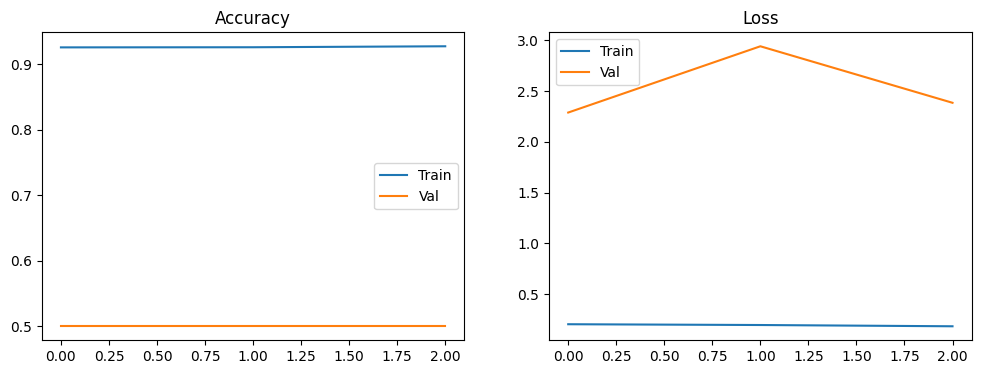

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()